# Lab 2 — Digital Image Fundamentals
**Course:** ARTI407 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**

This notebook covers the lab manual:
1. **Sampling and Quantization**
2. **Arithmetic Operations** (add, subtract, add constant)
3. **Set / Logical Operations** (union, intersection, difference, symmetric difference)
4. **Practical Tasks**

> **Note on images:** The lab references `lena_gray_256.tif`, `cameraman.tif`, `A.png`, `B.png`. Since those files aren't bundled with the notebook, this notebook uses built-in `skimage` images so every cell runs out of the box. To use your own image, just replace the loading line.

## Setup

In [1]:
import cv2
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt

%matplotlib inline

---
## Section 1 — Image Sampling and Quantization

- **Sampling** = how many pixels we keep (spatial resolution).
- **Quantization** = how many gray levels we keep (intensity resolution).

In [2]:
def sample_image(image, factor):
    """Downsamples the image by the given factor."""
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """Reduces the number of grayscale levels in the image."""
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1), plt.imshow(original, cmap='gray')
    plt.title('Original Image'), plt.axis('off')
    plt.subplot(1, 3, 2), plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image'), plt.axis('off')
    plt.subplot(1, 3, 3), plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image'), plt.axis('off')
    plt.show()

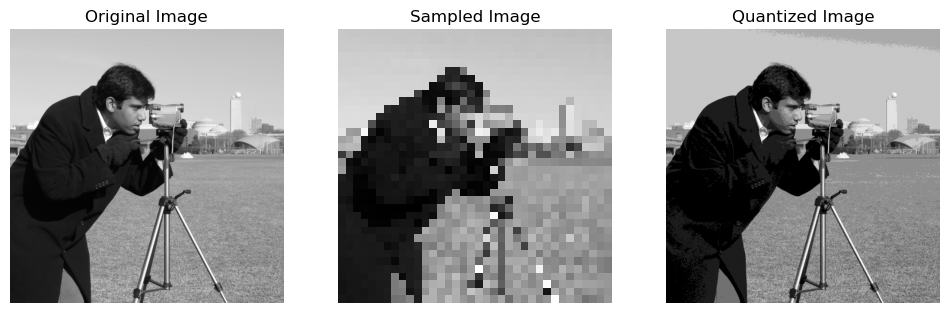

In [3]:
original_image = data.camera()

sampling_factor = 14
quantization_levels = 9

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

---
## Section 2 — Arithmetic Operations

Add two images by converting them to numpy arrays and adding element-wise.

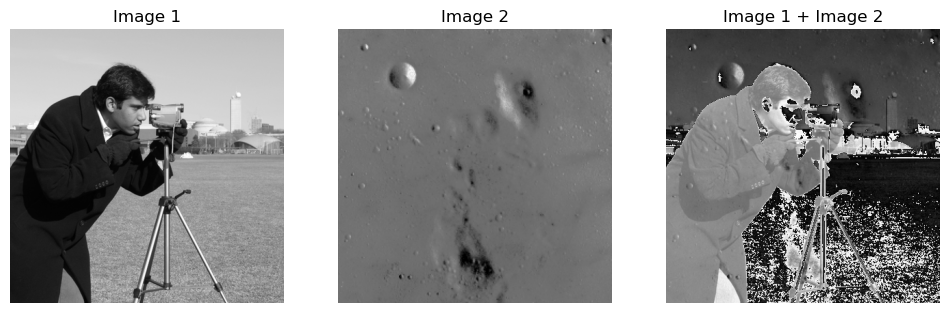

In [4]:
img1 = Image.fromarray(data.camera())
img2 = Image.fromarray(data.moon())

new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS)
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr
result_image = Image.fromarray(addition)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 + Image 2'), plt.axis('off')
plt.show()

---
## Section 3 — Set / Logical Operations

Pixel-wise bitwise operations on two images. Lab demo: **union (OR)**.

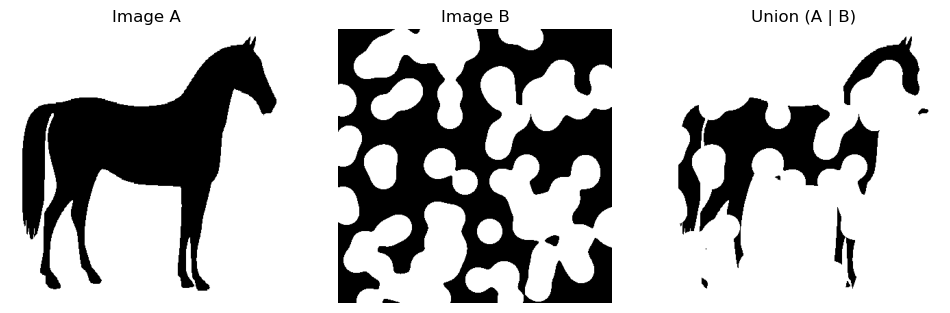

In [5]:
img3 = Image.fromarray(data.horse())
img4 = Image.fromarray(data.binary_blobs(length=400))

img3 = img3.resize(new_size, Image.Resampling.LANCZOS)
img4 = img4.resize(new_size, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
result_image_2 = Image.fromarray(union)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('Union (A | B)'), plt.axis('off')
plt.show()

---
# Practical Tasks

## Task 1 — Change sampling and quantization parameters and observe the effects

Try multiple values of the sampling factor and the number of quantization levels to see how each affects the image.

### 1a) Effect of sampling factor (spatial resolution)

<Figure size 1200x800 with 0 Axes>

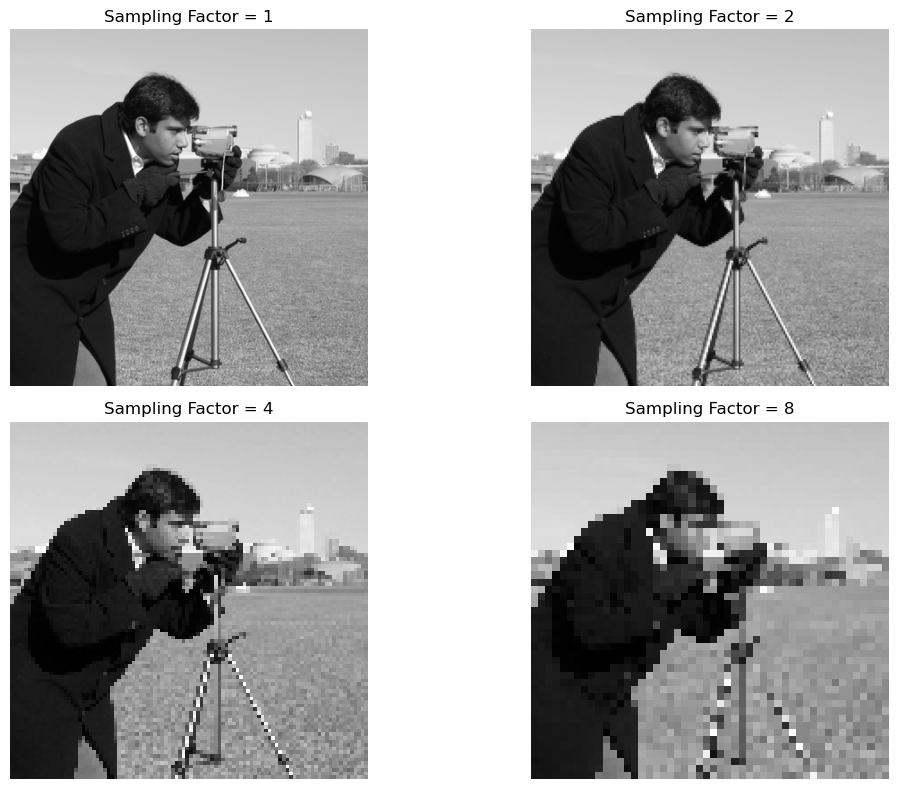

In [7]:
img1_array = np.array(img1)

sampling_factors = [1, 2, 4, 8]

plt.figure(figsize=(12, 8))

for i, factor in enumerate(sampling_factors):
    sampled_img = img1_array[::factor, ::factor]

    plt.subplot(2, 2, i + 1)
    plt.imshow(sampled_img, cmap='gray')
    plt.title(f'Sampling Factor = {factor}')
    plt.axis('off')

plt.tight_layout()
plt.show()

### 1b) Effect of quantization levels (intensity resolution)

<Figure size 1200x800 with 0 Axes>

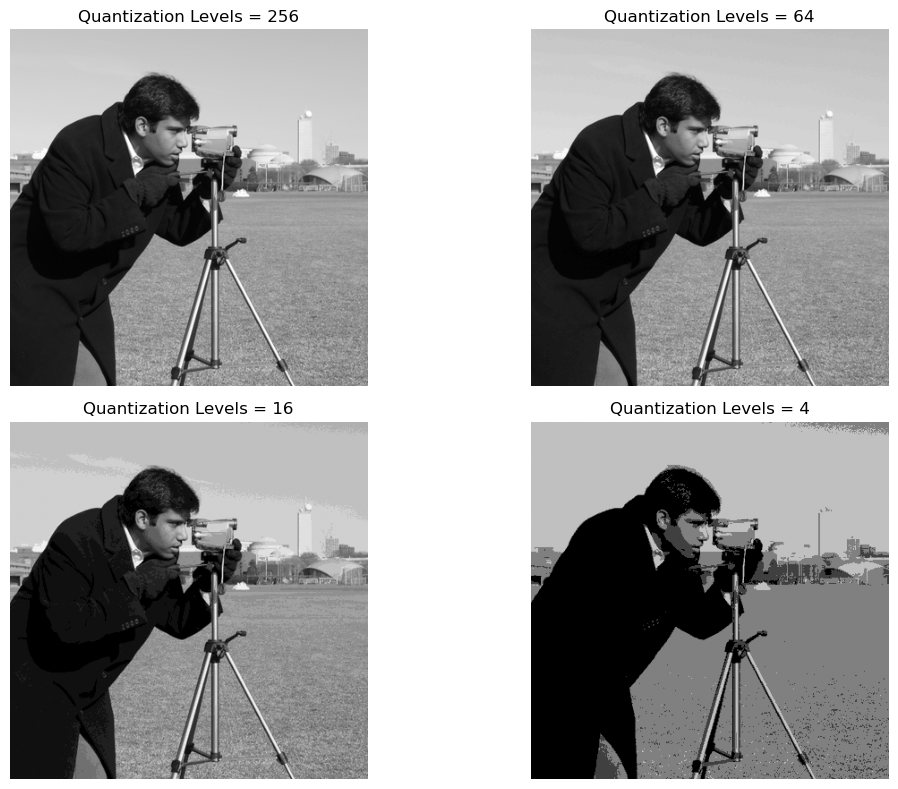

In [9]:

img1_array = np.array(img1.convert('L'))

quantization_levels = [256, 64, 16, 4]

plt.figure(figsize=(12, 8))

for i, levels in enumerate(quantization_levels):
    step = 256 // levels
    quantized_img = (img1_array // step) * step

    plt.subplot(2, 2, i + 1)
    plt.imshow(quantized_img, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Quantization Levels = {levels}')
    plt.axis('off')

plt.tight_layout()
plt.show()

---
## Task 2 — Image Arithmetic and Set Operations

Required operations:
1. Subtract two images and display the result
2. Add one image with a constant value 175
3. Set difference on two grayscale images
4. Symmetric difference on two grayscale images
5. Intersection on two grayscale images

### 2a) Subtract two images

In [10]:

img1_array = np.array(img1.convert('L'))
img2_array = np.array(img2.convert('L'))

img2_array = cv2.resize(
    img2_array,
    (img1_array.shape[1], img1_array.shape[0])
)

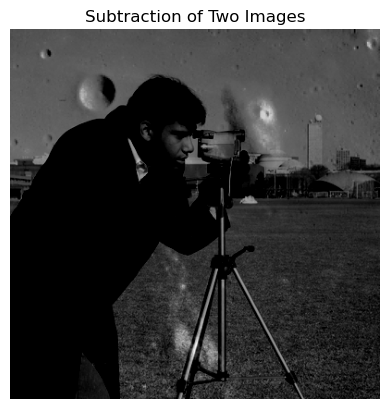

In [11]:
subtracted_img = cv2.subtract(img1_array, img2_array)

plt.imshow(subtracted_img, cmap='gray', vmin=0, vmax=255)
plt.title('Subtraction of Two Images')
plt.axis('off')
plt.show()

### 2b) Add image with constant value 175

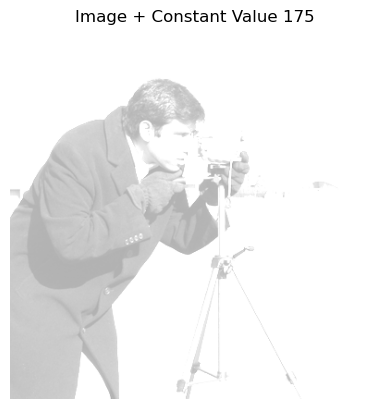

In [12]:
added_img = cv2.add(img1_array, 175)

plt.imshow(added_img, cmap='gray', vmin=0, vmax=255)
plt.title('Image + Constant Value 175')
plt.axis('off')
plt.show()

### 2c-2e) Set operations on grayscale images

| Operation | Bitwise formula | Meaning |
|---|---|---|
| **Intersection** | `A & B` | bits set in both |
| **Set difference** | `A & ~B` (A − B) | bits in A but not in B |
| **Symmetric difference** | `A ^ B` | bits in A or B but not both |
| **Union** (extra) | `A \| B` | bits in either |

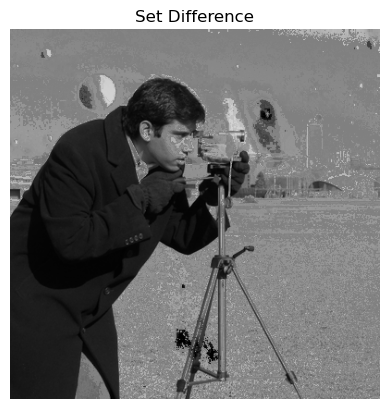

In [13]:
subtraction = cv2.subtract(img1_array, img2_array)

set_difference = cv2.bitwise_and(
    img1_array,
    cv2.bitwise_not(subtraction)
)

plt.imshow(set_difference, cmap='gray', vmin=0, vmax=255)
plt.title('Set Difference')
plt.axis('off')
plt.show()